# Rhabdoid cohorts clinical plots

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/home/msanchezg/miniconda3/envs/rhabdoids/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## SJD data

In [2]:
sjd_df = pd.read_csv('clinical_data/SJD_clinical_data_patient.tsv',sep='\t')
sjd_df = sjd_df[0:20]
exclude_pts = ['2','10','16','20']
sjd_df = sjd_df[~sjd_df['PATIENT_ID'].isin(exclude_pts)]
print(len(sjd_df))
sjd_df

16


,PATIENT_ID,GENDER,TUMOR_TYPE,TAB_DIAGNOSIS,TREATMENT,TAB_TTMT_START_DATE,TAB_TTMT_END_DATE,STATUS (Deceased/Alive),SAMPLE_AVAILABILITY,Diagnosis,Primary tumor,Metastasis (at debut),Site of relapse,Unnamed: 13
0,1,Male,MRT,8.29,mP6 protocol + surgery + radiotherapy,8.32,8.67,Alive,Diagnosis. Second look surgery (post-chemo),MRT,Pelvis,No,NaN,NaN
2,3,Male,MRT,4.75,St Jude protocol (incomplete) + surgery + radi...,4.79,5.05,Deceased,"Diagnosis, Relapse post chemo (Lung)",RTK,Kidney,No,"lung, lymph nodes",NaN
3,4,Female,MRT,0.02,No treatment,NaN,NaN,Deceased,"Diagnosis, Necropsy (no treatment)",MRT,Skin and soft tissue,lymph nodes,NaN,NaN
4,5,Male,MRT,13.50,St Jude protocol (incomplete),13.58,13.63,Deceased,"Diagnosis, Diagnosis, Necropsy (post chemo)",MRT,Paraspinal,"lymph nodes, lung",PD,NaN
5,6,Male,ATRT,1.52,Boston protocol,1.56,NaN,Deceased,"Post chemo, Necropsy (post chemo)",MRT,CNS (cervical),lung,PD,NaN
6,7,Male,ATRT,1.98,surgery + COG,1.98,2.19,Alive,Recurrence (post chemo),ATRT,Brain,No,PD,NaN
7,8,Male,ATRT,3.00,surgery + Dana Farber + radiotherapy,3.06,3.4,Alive,Diagnosis,ATRT,Brain,No,NaN,NaN
8,9,Female,MRT,0.48,mP6 protocol + surgery,0.45,0.52,Deceased,"Diagnosis, Second look surgery (post chemo)",MRT,Liver,No,PD,NaN
10,11,Female,ATRT,5.57,Dana Farber + surgery + radiotherapy + retinoi...,5.56,9.2,Deceased,Diagnosis,ATRT,Brain,CSF,NaN,NaN
11,12,Male,MRT,0.62,mP6 + surgery + radiotherapy + tamoxifen + ret...,0.17,NaN,Deceased,"Progression (post chemo), Progression (post ch...",MRT,Armpit,lung,"PD (LUNG, LIVER, KIDNEYS)",NaN


## TARGET data

In [3]:
empty_cell = "'--"
empty_col = [empty_cell] * 69

In [5]:
target_df = pd.read_csv('clinical_data/TARGET_clinical_data.tsv',sep='\t')
cols = list(target_df)
info_cols = []
for col in cols:
    column = target_df[col].tolist()
    if column != empty_col:
        info_cols.append(col)
target_df = target_df[info_cols]
target_df

,case_id,case_submitter_id,project_id,days_to_death,ethnicity,gender,race,vital_status,age_at_diagnosis,cog_renal_stage,days_to_last_follow_up,last_known_disease_status,morphology,primary_diagnosis,progression_or_recurrence,site_of_resection_or_biopsy,tissue_or_organ_of_origin,tumor_grade,year_of_diagnosis
0,01444de8-344b-566e-a461-8ef82b0796d8,TARGET-52-PAKPEW,TARGET-RT,153,not hispanic or latino,male,white,Dead,950,Stage IV,153.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2001
1,0f9e1dc9-5003-5628-8c3f-5e599a13c90d,TARGET-52-PAUEKW,TARGET-RT,'--,not hispanic or latino,female,other,Alive,5386,Stage III,625.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2011
2,105d2431-78e7-5e34-b620-0b9d4fd9d1a3,TARGET-52-PASGGN,TARGET-RT,112,not hispanic or latino,male,white,Dead,130,Stage IV,112.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2008
3,122eba47-a308-5c80-a332-06b37f12cc3a,TARGET-52-PAJLRA,TARGET-RT,16,Unknown,female,white,Dead,3,Stage III,16.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,1996
4,153c5c30-41d5-5369-873f-d086ead699a4,TARGET-52-PASVDP,TARGET-RT,'--,not hispanic or latino,female,white,Alive,141,Stage III,1.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,External upper lip,External upper lip,Not Reported,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,ea300498-806d-56cf-9cca-adb64f869e7b,TARGET-52-PARUGK,TARGET-RT,'--,hispanic or latino,male,white,Alive,220,Stage III,1.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2008
65,ead9a4f1-e7d2-5341-93a0-a67267c28728,TARGET-52-PASAMZ,TARGET-RT,'--,hispanic or latino,female,white,Alive,3027,Stage I,1746.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,External upper lip,External upper lip,Not Reported,2008
66,ee33dcef-f61c-5ee0-9c65-a4eb475a2406,TARGET-52-PAVDPR,TARGET-RT,'--,not hispanic or latino,male,white,Unknown,749,Stage IV,'--,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2012
67,ef42d20f-5f3e-58c6-9d52-0a2aa48a162c,TARGET-52-PAJNFZ,TARGET-RT,48,Unknown,male,black or african american,Dead,592,Stage IV,48.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,1999


In [6]:
target_df.groupby('ethnicity').count()

,case_id,case_submitter_id,project_id,days_to_death,gender,race,vital_status,age_at_diagnosis,cog_renal_stage,days_to_last_follow_up,last_known_disease_status,morphology,primary_diagnosis,progression_or_recurrence,site_of_resection_or_biopsy,tissue_or_organ_of_origin,tumor_grade,year_of_diagnosis
ethnicity,,,,,,,,,,,,,,,,,,
Unknown,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10
hispanic or latino,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
not hispanic or latino,48,48,48,48,48,48,48,48,48,48,48,48,48,48,48,48,48,48


In [7]:
target_df.groupby('gender').count()

,case_id,case_submitter_id,project_id,days_to_death,ethnicity,race,vital_status,age_at_diagnosis,cog_renal_stage,days_to_last_follow_up,last_known_disease_status,morphology,primary_diagnosis,progression_or_recurrence,site_of_resection_or_biopsy,tissue_or_organ_of_origin,tumor_grade,year_of_diagnosis
gender,,,,,,,,,,,,,,,,,,
female,33,33,33,33,33,33,33,33,33,33,33,33,33,33,33,33,33,33
male,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36


In [8]:
target_df.groupby('race').count()

,case_id,case_submitter_id,project_id,days_to_death,ethnicity,gender,vital_status,age_at_diagnosis,cog_renal_stage,days_to_last_follow_up,last_known_disease_status,morphology,primary_diagnosis,progression_or_recurrence,site_of_resection_or_biopsy,tissue_or_organ_of_origin,tumor_grade,year_of_diagnosis
race,,,,,,,,,,,,,,,,,,
Unknown,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
black or african american,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
other,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
white,50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,50


In [9]:
target_df.groupby('cog_renal_stage').count()

,case_id,case_submitter_id,project_id,days_to_death,ethnicity,gender,race,vital_status,age_at_diagnosis,days_to_last_follow_up,last_known_disease_status,morphology,primary_diagnosis,progression_or_recurrence,site_of_resection_or_biopsy,tissue_or_organ_of_origin,tumor_grade,year_of_diagnosis
cog_renal_stage,,,,,,,,,,,,,,,,,,
Not Reported,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Stage I,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
Stage II,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14
Stage III,34,34,34,34,34,34,34,34,34,34,34,34,34,34,34,34,34,34
Stage IV,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18


In [10]:
target_df.groupby('site_of_resection_or_biopsy').count()

,case_id,case_submitter_id,project_id,days_to_death,ethnicity,gender,race,vital_status,age_at_diagnosis,cog_renal_stage,days_to_last_follow_up,last_known_disease_status,morphology,primary_diagnosis,progression_or_recurrence,tissue_or_organ_of_origin,tumor_grade,year_of_diagnosis
site_of_resection_or_biopsy,,,,,,,,,,,,,,,,,,
External upper lip,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6
"Kidney, NOS",61,61,61,61,61,61,61,61,61,61,61,61,61,61,61,61,61,61
Liver,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


In [11]:
target_df.groupby('tissue_or_organ_of_origin').count()

,case_id,case_submitter_id,project_id,days_to_death,ethnicity,gender,race,vital_status,age_at_diagnosis,cog_renal_stage,days_to_last_follow_up,last_known_disease_status,morphology,primary_diagnosis,progression_or_recurrence,site_of_resection_or_biopsy,tumor_grade,year_of_diagnosis
tissue_or_organ_of_origin,,,,,,,,,,,,,,,,,,
External upper lip,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6
"Kidney, NOS",61,61,61,61,61,61,61,61,61,61,61,61,61,61,61,61,61,61
Liver,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


In [12]:
# get patients with bam
target_samples_list = []
for n in range(1,8):
    df1 = pd.read_csv('variant_calling/target_cohort/sarek_results/input_fastq_batch'+str(n)+'.csv')
    p = list(df1['patient'].unique())
    target_samples_list = target_samples_list + p
print(len(target_samples_list))
target_samples_list

56


['PASZYE',
 'PARZBI',
 'PARRCL',
 'PATBLF',
 'PAJNFZ',
 'PAKLYZ',
 'PASADZ',
 'PASCDH',
 'PASGCL',
 'PASRHU',
 'PASVDP',
 'PASWZZ',
 'PASYNF',
 'PAEHIP',
 'PAJLWM',
 'PAJMRB',
 'PAJNER',
 'PAJNFP',
 'PAKHTL',
 'PATAFT',
 'PATDVL',
 'PATENH',
 'PATFXW',
 'PAUCGJ',
 'PAUEKW',
 'PAUFVP',
 'PAUGYZ',
 'PAUHAZ',
 'PAVITI',
 'PAVYDM',
 'PAVYKD',
 'PAWDGA',
 'PAWFWK',
 'PABKLN',
 'PADWRZ',
 'PADYZI',
 'PAJMBW',
 'PAKTCT',
 'PARECB',
 'PAREWI',
 'PARGRN',
 'PARIRN',
 'PASDLA',
 'PASXNA',
 'PATFZZ',
 'PATXEE',
 'PATXKA',
 'PAUDPV',
 'PAUNPA',
 'PAVCKS',
 'PAWFBL',
 'PARPFY',
 'PARTKH',
 'PARUGK',
 'PARZRH',
 'PASABD']

In [13]:
target_df['PATIENT'] = target_df['case_submitter_id'].str.split('-',expand=True)[2]
target_df['AGE_DIAGNOSIS'] = target_df['age_at_diagnosis'] / 365
target_df = target_df[target_df['PATIENT'].isin(target_samples_list)]

target_df[['PATIENT','AGE_DIAGNOSIS']]

,PATIENT,AGE_DIAGNOSIS
1,PAUEKW,14.756164
4,PASVDP,0.386301
5,PAREWI,0.841096
6,PAUNPA,2.843836
7,PATXKA,0.279452
8,PAJLWM,0.794521
9,PATDVL,0.400000
11,PAVYDM,0.463014
12,PABKLN,1.095890
13,PAJMRB,1.482192


## ST JUDE data

In [14]:
import json

In [15]:
stjude_dict = json.load(open('sample_ids/sample_stjude_ids.json','rb'))
stjude_tumors = [stjude_dict[pt]['tumor1'] for pt in stjude_dict.keys()]
bad_quality_samples = ['SJBT032047_D1','SJBT033133_D3']
xenograft = ['SJMRT063832_X1']
no_age_data = ['SJMRT014754_D1']
exclude_samples =  bad_quality_samples + xenograft+ no_age_data
stjude_tumors = [t for t in stjude_tumors if t not in exclude_samples]
print(len(stjude_tumors))
stjude_tumors

16


['SJMRT015723_D1',
 'SJBT030128_D1',
 'SJBT030255_D1',
 'SJBT030581_D1',
 'SJBT030707_D2',
 'SJBT030896_D1',
 'SJBT030997_D1',
 'SJBT031235_D1',
 'SJBT031605_D1',
 'SJBT031948_D2',
 'SJBT032346_D1',
 'SJBT032393_D1',
 'SJBT032417_D2',
 'SJBT033236_D2',
 'SJBT034089_D1',
 'SJBT034110_D2']

In [81]:
stjude_df = pd.read_csv('clinical_data/StJude_clinical_data.txt',sep='\t')
df1 = pd.read_csv('variant_calling/stjude_cohort/sarek_results/input_fastq.csv')
pts = df1['patient'].unique()
stjude_df = stjude_df[stjude_df['subject_name'].isin(pts)]
stjude_df = stjude_df[stjude_df['sample_name'].isin(stjude_tumors)]
stjude_df = stjude_df[stjude_df['sample_type'].isin(['Diagnosis','Other','Metastasis'])]
stjude_df = stjude_df[stjude_df['file_path'].str.endswith('bam')]
stjude_df = stjude_df[['subject_name','sample_name','sj_long_disease_name',
       'attr_age_at_diagnosis', 'attr_diagnosis', 'attr_sex', 'attr_ethnicity',
       'attr_race','attr_subtype_biomarkers',
       'sj_associated_diagnoses',
       'attr_diagnosis_group', 'sj_access_unit',
       'sj_diseases', 'sj_datasets',
       'sj_disease_hierarchy_code', 'sj_disease_hierarchy_name'       ]]
stjude_df

,subject_name,sample_name,sj_long_disease_name,attr_age_at_diagnosis,attr_diagnosis,attr_sex,attr_ethnicity,attr_race,attr_subtype_biomarkers,sj_associated_diagnoses,attr_diagnosis_group,sj_access_unit,sj_diseases,sj_datasets,sj_disease_hierarchy_code,sj_disease_hierarchy_name
3,SJ030255,SJBT030255_D1,Atypical Teratoid/Rhabdoid Tumors,2.42,Atypical Teratoid Rhabdoid Tumor,Male,Not Hispanic Or Latino,Asian,Not Available,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Genomes 4 Kids (G4K),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
4,SJ030128,SJBT030128_D1,Atypical Teratoid/Rhabdoid Tumors,1.17,Atypical Teratoid Rhabdoid Tumor,Female,Not Hispanic Or Latino,White,Not Available,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Genomes 4 Kids (G4K),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
12,SJ030581,SJBT030581_D1,Atypical Teratoid/Rhabdoid Tumors,10.25,"ATYPICAL TERATOID RHABDOID TUMOR, TEMPORAL LOB...",Male,Not Hispanic Or Latino,Black Or African American,NaN,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
14,SJ030997,SJBT030997_D1,Atypical Teratoid/Rhabdoid Tumors,0.50,"ATYPICAL TERATOID RHABDOID TUMOR, TEMPORAL LOB...",Female,Hispanic Or Latino,White,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
35,SJ030896,SJBT030896_D1,Atypical Teratoid/Rhabdoid Tumors,2.75,"ATYPICAL TERATOID RHABDOID TUMOR, LEFT FRONTAL...",Male,Not Hispanic Or Latino,Other,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
41,SJ030707,SJBT030707_D2,Atypical Teratoid/Rhabdoid Tumors,1.58,"ATYPICAL TERATOID RHABDOID TUMOR, POSTERIOR FOSSA",Male,Not Hispanic Or Latino,Black Or African American,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
45,SJ031235,SJBT031235_D1,Atypical Teratoid/Rhabdoid Tumors,0.67,"ATYPICAL TERATOID/RHABDOID TUMOR, FORTH VENTRICLE",Female,Not Hispanic Or Latino,White,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
46,SJ015723,SJMRT015723_D1,"Rhabdoid Cancer, Kidney",1.00,Not Available,Male,Not Available,Not Available,Not Available,"Rhabdoid Cancer, Kidney (MRT)",Solid Tumor,PCGP,MRT,Childhood Solid Tumor Network (CSTN),ST|KID|MRT,"Solid Tumor|Kidney|Rhabdoid Cancer, Kidney"
65,SJ031605,SJBT031605_D1,Atypical Teratoid/Rhabdoid Tumors,2.25,"ATYPICAL TERATOID RHABDOID TUMOR, FRONTOTEMPOR...",Male,Not Hispanic Or Latino,Declined To Respond,NF1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
75,SJ032393,SJBT032393_D1,Atypical Teratoid/Rhabdoid Tumors,14.00,Malignant neoplasm of overlapping sites of brain,Female,Not Hispanic Or Latino,White,SMARCB1 LOSS,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...


In [17]:
stjude_df.groupby('sj_diseases').count()

,subject_name,sample_name,sj_long_disease_name,attr_age_at_diagnosis,attr_diagnosis,attr_sex,attr_ethnicity,attr_race,attr_subtype_biomarkers,sj_associated_diagnoses,attr_diagnosis_group,sj_access_unit,sj_datasets,sj_disease_hierarchy_code,sj_disease_hierarchy_name
sj_diseases,,,,,,,,,,,,,,,
ATRT,15,15,15,15,15,15,15,15,14,15,15,15,15,15,15
MRT,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [18]:
stjude_df.groupby('sj_long_disease_name').count()

,subject_name,sample_name,attr_age_at_diagnosis,attr_diagnosis,attr_sex,attr_ethnicity,attr_race,attr_subtype_biomarkers,sj_associated_diagnoses,attr_diagnosis_group,sj_access_unit,sj_diseases,sj_datasets,sj_disease_hierarchy_code,sj_disease_hierarchy_name
sj_long_disease_name,,,,,,,,,,,,,,,
Atypical Teratoid/Rhabdoid Tumors,15,15,15,15,15,15,15,14,15,15,15,15,15,15,15
"Rhabdoid Cancer, Kidney",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [19]:
stjude_df.groupby('attr_diagnosis').count()

,subject_name,sample_name,sj_long_disease_name,attr_age_at_diagnosis,attr_sex,attr_ethnicity,attr_race,attr_subtype_biomarkers,sj_associated_diagnoses,attr_diagnosis_group,sj_access_unit,sj_diseases,sj_datasets,sj_disease_hierarchy_code,sj_disease_hierarchy_name
attr_diagnosis,,,,,,,,,,,,,,,
"ATYPICAL TERATOID RHABDOID TUMOR, FRONTOTEMPOROPARIETAL, RIGHT",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"ATYPICAL TERATOID RHABDOID TUMOR, INI1-ALTERED, PINEAL GLAND",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"ATYPICAL TERATOID RHABDOID TUMOR, LEFT FRONTAL LOBE",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"ATYPICAL TERATOID RHABDOID TUMOR, LOSS OF INI1 EXPRESSION, BASAL GANGLIA, RIGHT",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"ATYPICAL TERATOID RHABDOID TUMOR, LOSS OF INI1 EXPRESSION, RETAINED EXPRESSION OF BRG1, PINEAL REGION",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"ATYPICAL TERATOID RHABDOID TUMOR, PINEAL GLAND",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"ATYPICAL TERATOID RHABDOID TUMOR, POSTERIOR FOSSA",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
"ATYPICAL TERATOID RHABDOID TUMOR, TEMPORAL LOBE, RIGHT",2,2,2,2,2,2,2,1,2,2,2,2,2,2,2
"ATYPICAL TERATOID/RHABDOID TUMOR, FORTH VENTRICLE",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [20]:
stjude_df.groupby('attr_sex').count()

,subject_name,sample_name,sj_long_disease_name,attr_age_at_diagnosis,attr_diagnosis,attr_ethnicity,attr_race,attr_subtype_biomarkers,sj_associated_diagnoses,attr_diagnosis_group,sj_access_unit,sj_diseases,sj_datasets,sj_disease_hierarchy_code,sj_disease_hierarchy_name
attr_sex,,,,,,,,,,,,,,,
Female,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
Male,8,8,8,8,8,8,8,7,8,8,8,8,8,8,8


In [21]:
stjude_df.groupby('attr_ethnicity').count()

,subject_name,sample_name,sj_long_disease_name,attr_age_at_diagnosis,attr_diagnosis,attr_sex,attr_race,attr_subtype_biomarkers,sj_associated_diagnoses,attr_diagnosis_group,sj_access_unit,sj_diseases,sj_datasets,sj_disease_hierarchy_code,sj_disease_hierarchy_name
attr_ethnicity,,,,,,,,,,,,,,,
Hispanic Or Latino,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Not Available,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Not Hispanic Or Latino,14,14,14,14,14,14,14,13,14,14,14,14,14,14,14


In [22]:
stjude_df.groupby('attr_race').count()

,subject_name,sample_name,sj_long_disease_name,attr_age_at_diagnosis,attr_diagnosis,attr_sex,attr_ethnicity,attr_subtype_biomarkers,sj_associated_diagnoses,attr_diagnosis_group,sj_access_unit,sj_diseases,sj_datasets,sj_disease_hierarchy_code,sj_disease_hierarchy_name
attr_race,,,,,,,,,,,,,,,
Asian,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
Black Or African American,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2
Declined To Respond,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Native Hawaiian Or Other Pacific Islander,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Not Available,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Other,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
White,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8


In [23]:
stjude_df.groupby('sj_associated_diagnoses').count()

,subject_name,sample_name,sj_long_disease_name,attr_age_at_diagnosis,attr_diagnosis,attr_sex,attr_ethnicity,attr_race,attr_subtype_biomarkers,attr_diagnosis_group,sj_access_unit,sj_diseases,sj_datasets,sj_disease_hierarchy_code,sj_disease_hierarchy_name
sj_associated_diagnoses,,,,,,,,,,,,,,,
Atypical Teratoid/Rhabdoid Tumors (ATRT),15,15,15,15,15,15,15,15,14,15,15,15,15,15,15
"Rhabdoid Cancer, Kidney (MRT)",1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


## PMC case

In [24]:
pmc_dict = json.load(open('sample_ids/sample_pmc_ids.json','rb'))
pmc_loc_dict = {'OMEN':'Omentum',
                'DIAF':'Diaphragm',
                'LN':'Lymph node',
                'LNMETA':'Lymph node'}

In [25]:
pmc_df = pd.DataFrame([])
for t in (t for t in pmc_dict['PMC01'].keys() if t not in ['normal','normal2']):
    tumor_id = pmc_dict['PMC01'][t]
    pmc_case_dict = {'PATIENT':'PMC01',
                     'SEX':'Female',
                     'TUMOR_TYPE':'MRT',
                     'COHORT':'PMC',
                    'SAMPLE_ID':tumor_id,
                    'SAMPLE_TYPE':'post ttmt',
                    'AGE_DIAGNOSIS':2.5,
                    'PRY_TUMOR_SITE':'Soft tissue',
                    'SAMPLE_LOCATION': pmc_loc_dict[tumor_id],
                    'PATIENT':'PMC01',
                    'SAMPLE':'PMC01_t'+t[-1]}
    pmc_df = pd.concat([pmc_df,pd.DataFrame([pmc_case_dict])])
pmc_df

,PATIENT,SEX,TUMOR_TYPE,COHORT,SAMPLE_ID,SAMPLE_TYPE,AGE_DIAGNOSIS,PRY_TUMOR_SITE,SAMPLE_LOCATION,SAMPLE
0,PMC01,Female,MRT,PMC,DIAF,post ttmt,2.5,Soft tissue,Diaphragm,PMC01_t1
0,PMC01,Female,MRT,PMC,OMEN,post ttmt,2.5,Soft tissue,Omentum,PMC01_t2
0,PMC01,Female,MRT,PMC,LN,post ttmt,2.5,Soft tissue,Lymph node,PMC01_t3
0,PMC01,Female,MRT,PMC,LNMETA,post ttmt,2.5,Soft tissue,Lymph node,PMC01_t4


## CONCAT tables

In [26]:
sjd_df.columns

Index(['PATIENT_ID', 'GENDER', 'TUMOR_TYPE', 'TAB_DIAGNOSIS', 'TREATMENT',
       'TAB_TTMT_START_DATE', 'TAB_TTMT_END_DATE', 'STATUS (Deceased/Alive)',
       'SAMPLE_AVAILABILITY', 'Diagnosis', 'Primary tumor',
       'Metastasis (at debut)', 'Site of relapse', 'Unnamed: 13'],
      dtype='object')

In [28]:
cols = ['PATIENT','AGE_DIAGNOSIS','SEX','TUMOR_TYPE','PRY_TUMOR_SITE','COHORT']

In [29]:
sjd_df['PATIENT'] = sjd_df['PATIENT_ID'].replace('14*','14')
sjd_df['TUMOR_TYPE'] = sjd_df['TUMOR_TYPE'].replace('SMARCA4mut','ATRT')
sjd_df['PRY_TUMOR_SITE'] = sjd_df['Primary tumor'].replace('Skin and soft tissue','Soft tissue').replace('CNS (cervical)','Brain').replace('Laterocervical soft tissue','Soft tissue').replace('Soft tissue (multiple tumor masses)','Soft tissue')
sjd_df['SEX'] = sjd_df['GENDER']
sjd_df['AGE_DIAGNOSIS'] = sjd_df['TAB_DIAGNOSIS']
sjd_df['COHORT'] = 'SJD'
sjd_df[cols]

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
0,1,8.29,Male,MRT,Pelvis,SJD
2,3,4.75,Male,MRT,Kidney,SJD
3,4,0.02,Female,MRT,Soft tissue,SJD
4,5,13.50,Male,MRT,Paraspinal,SJD
5,6,1.52,Male,ATRT,Brain,SJD
6,7,1.98,Male,ATRT,Brain,SJD
7,8,3.00,Male,ATRT,Brain,SJD
8,9,0.48,Female,MRT,Liver,SJD
10,11,5.57,Female,ATRT,Brain,SJD
11,12,0.62,Male,MRT,Armpit,SJD


In [30]:
target_df.columns

Index(['case_id', 'case_submitter_id', 'project_id', 'days_to_death',
       'ethnicity', 'gender', 'race', 'vital_status', 'age_at_diagnosis',
       'cog_renal_stage', 'days_to_last_follow_up',
       'last_known_disease_status', 'morphology', 'primary_diagnosis',
       'progression_or_recurrence', 'site_of_resection_or_biopsy',
       'tissue_or_organ_of_origin', 'tumor_grade', 'year_of_diagnosis',
       'PATIENT', 'AGE_DIAGNOSIS'],
      dtype='object')

In [31]:
target_df['SEX'] = target_df['gender'].replace('female','Female')
target_df['SEX'] = target_df['SEX'].replace('male','Male')
target_df['TUMOR_TYPE'] = target_df['primary_diagnosis'].replace('Malignant rhabdoid tumor','MRT')
target_df['PRY_TUMOR_SITE'] = target_df['site_of_resection_or_biopsy'].replace('Kidney, NOS','Kidney')
target_df['COHORT'] = 'TARGET'
target_df[cols]

/tmp/ipykernel_3311154/16774340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df['SEX'] = target_df['gender'].replace('female','Female')
/tmp/ipykernel_3311154/16774340.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df['SEX'] = target_df['SEX'].replace('male','Male')
/tmp/ipykernel_3311154/16774340.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
1,PAUEKW,14.756164,Female,MRT,Kidney,TARGET
4,PASVDP,0.386301,Female,MRT,External upper lip,TARGET
5,PAREWI,0.841096,Female,MRT,Kidney,TARGET
6,PAUNPA,2.843836,Male,MRT,Kidney,TARGET
7,PATXKA,0.279452,Female,MRT,Liver,TARGET
8,PAJLWM,0.794521,Male,MRT,Kidney,TARGET
9,PATDVL,0.400000,Male,MRT,Kidney,TARGET
11,PAVYDM,0.463014,Female,MRT,Kidney,TARGET
12,PABKLN,1.095890,Male,MRT,Kidney,TARGET
13,PAJMRB,1.482192,Female,MRT,Kidney,TARGET


In [32]:
stjude_df.columns

Index(['subject_name', 'sample_name', 'sj_long_disease_name',
       'attr_age_at_diagnosis', 'attr_diagnosis', 'attr_sex', 'attr_ethnicity',
       'attr_race', 'attr_subtype_biomarkers', 'sj_associated_diagnoses',
       'attr_diagnosis_group', 'sj_access_unit', 'sj_diseases', 'sj_datasets',
       'sj_disease_hierarchy_code', 'sj_disease_hierarchy_name'],
      dtype='object')

In [33]:
stjude_df['PATIENT'] = stjude_df['subject_name']
stjude_df['AGE_DIAGNOSIS'] = stjude_df['attr_age_at_diagnosis']
stjude_df['SEX'] = stjude_df['attr_sex']
stjude_df['TUMOR_TYPE'] = stjude_df['sj_associated_diagnoses'].str.split('(',expand=True)[1].str.split(')',expand=True)[0]
stjude_df['PRY_TUMOR_SITE'] = stjude_df['TUMOR_TYPE'].replace('ATRT','Brain').replace('MRT','Kidney')
stjude_df['COHORT'] = 'StJude'
stjude_df[cols]

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
3,SJ030255,2.42,Male,ATRT,Brain,StJude
4,SJ030128,1.17,Female,ATRT,Brain,StJude
12,SJ030581,10.25,Male,ATRT,Brain,StJude
14,SJ030997,0.50,Female,ATRT,Brain,StJude
35,SJ030896,2.75,Male,ATRT,Brain,StJude
41,SJ030707,1.58,Male,ATRT,Brain,StJude
45,SJ031235,0.67,Female,ATRT,Brain,StJude
46,SJ015723,1.00,Male,MRT,Kidney,StJude
65,SJ031605,2.25,Male,ATRT,Brain,StJude
75,SJ032393,14.00,Female,ATRT,Brain,StJude


In [34]:
clinical_df = pd.concat([sjd_df[cols],target_df[cols],stjude_df[cols],pmc_df[cols]])
clinical_df.drop_duplicates(inplace=True)
clinical_df

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
0,1,8.29,Male,MRT,Pelvis,SJD
2,3,4.75,Male,MRT,Kidney,SJD
3,4,0.02,Female,MRT,Soft tissue,SJD
4,5,13.5,Male,MRT,Paraspinal,SJD
5,6,1.52,Male,ATRT,Brain,SJD
...,...,...,...,...,...,...
91,SJ032417,0.17,Female,ATRT,Brain,StJude
103,SJ033236,0.75,Female,ATRT,Brain,StJude
124,SJ034089,0.42,Male,ATRT,Brain,StJude
126,SJ034110,0.67,Male,ATRT,Brain,StJude


In [35]:
clinical_df[['COHORT','PATIENT']].groupby('COHORT').count()

,PATIENT
COHORT,
PMC,1
SJD,16
StJude,16
TARGET,56


In [36]:
target_df.columns

Index(['case_id', 'case_submitter_id', 'project_id', 'days_to_death',
       'ethnicity', 'gender', 'race', 'vital_status', 'age_at_diagnosis',
       'cog_renal_stage', 'days_to_last_follow_up',
       'last_known_disease_status', 'morphology', 'primary_diagnosis',
       'progression_or_recurrence', 'site_of_resection_or_biopsy',
       'tissue_or_organ_of_origin', 'tumor_grade', 'year_of_diagnosis',
       'PATIENT', 'AGE_DIAGNOSIS', 'SEX', 'TUMOR_TYPE', 'PRY_TUMOR_SITE',
       'COHORT'],
      dtype='object')

In [37]:
#check sample with MYCN amp
cols = ['cog_renal_stage', 'days_to_last_follow_up',
       'last_known_disease_status', 'morphology', 'primary_diagnosis',
       'progression_or_recurrence', 'site_of_resection_or_biopsy',
       'tissue_or_organ_of_origin', 'tumor_grade', 'year_of_diagnosis',
       'PATIENT', 'AGE_DIAGNOSIS', 'SEX', 'TUMOR_TYPE', 'PRY_TUMOR_SITE',
       'COHORT']
target_df[cols][target_df['PATIENT']=='PAKLYZ']

,cog_renal_stage,days_to_last_follow_up,last_known_disease_status,morphology,primary_diagnosis,progression_or_recurrence,site_of_resection_or_biopsy,tissue_or_organ_of_origin,tumor_grade,year_of_diagnosis,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
43,Stage III,'--,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2000,PAKLYZ,1.443836,Male,MRT,Kidney,TARGET


## Age distribution

In [38]:
import matplotlib as mpl

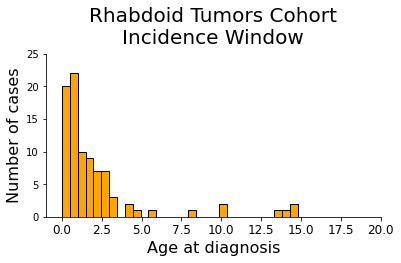

In [39]:
plt.figure(figsize=(6,3))
ages = [float(s) for s in list(clinical_df.AGE_DIAGNOSIS)]
plt.hist(x=ages,bins=30,color='orange',edgecolor='k')
plt.xlim(-1,20)
plt.ylim(0,25)
plt.xticks(size=12)
plt.xlabel('Age at diagnosis',size=16)
plt.ylabel('Number of cases',size=16)
plt.title('Rhabdoid Tumors Cohort\nIncidence Window', pad=10, size=20)
sns.despine()
plt.savefig('plots/RT_cohort_IncidenceWindow.svg',format='svg',dpi=300,bbox_inches='tight')
plt.show()

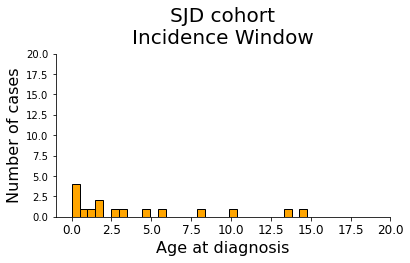

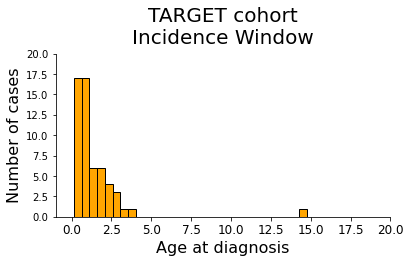

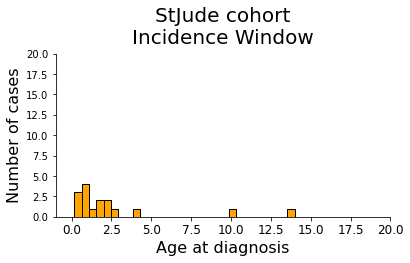

In [40]:
for cohort in ['SJD','TARGET','StJude']:
    
    cohort_df = clinical_df[clinical_df['COHORT']==cohort]
    
    plt.figure(figsize=(6,3))
    ages = [float(s) for s in list(cohort_df.AGE_DIAGNOSIS)]
    plt.hist(x=ages,bins=30,color='orange',edgecolor='k')
    plt.xlim(-1,20)
    plt.ylim(0,20)
    plt.xticks(size=12)
    plt.xlabel('Age at diagnosis',size=16)
    plt.ylabel('Number of cases',size=16)
    plt.title(cohort+' cohort\nIncidence Window', pad=10, size=20)
    sns.despine()
    plt.show()

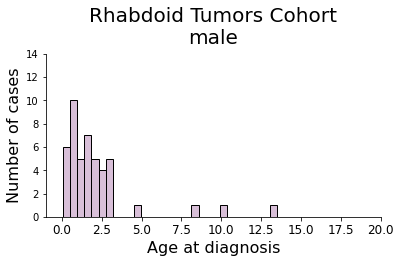

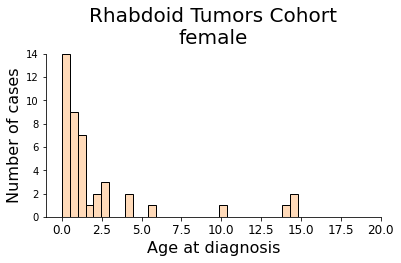

In [41]:
for sex in ['Male','Female']:
    df = clinical_df[clinical_df['SEX']==sex]
    plt.figure(figsize=(6,3))
    if sex == 'Male':
        color = 'thistle'
    else:
        color = 'peachpuff'
    ages = [float(s) for s in list(df.AGE_DIAGNOSIS)]
    plt.hist(x=ages,bins=30,color=color,edgecolor='k')
    # sns.displot(ages,bins=30,kind='hist',color=color,height=3,aspect=2)
    plt.xlim(-1,20)
    plt.ylim(0,14)
    plt.xticks(size=12)
    plt.xlabel('Age at diagnosis',size=16)
    plt.ylabel('Number of cases',size=16)
    plt.title('Rhabdoid Tumors Cohort\n'+sex.lower(), pad=10, size=20)
    sns.despine()
    plt.show()

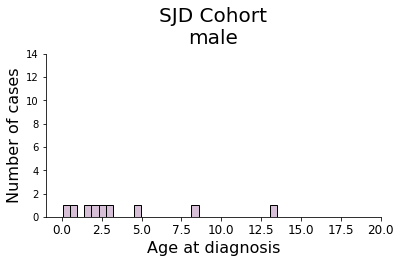

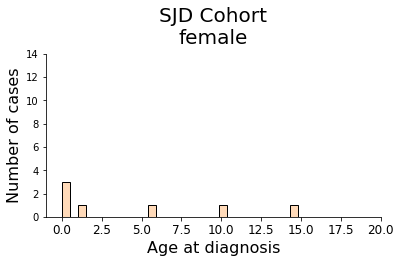

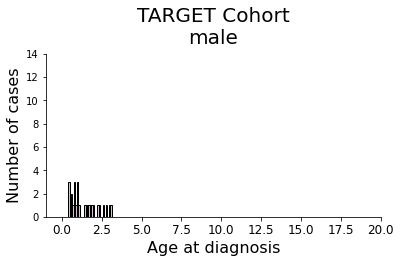

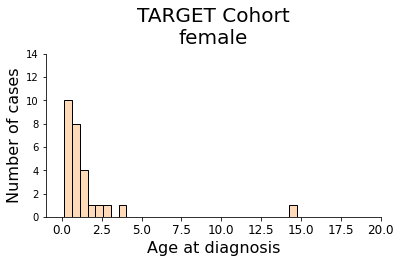

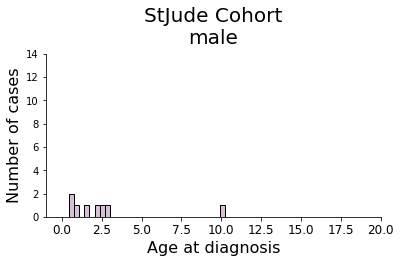

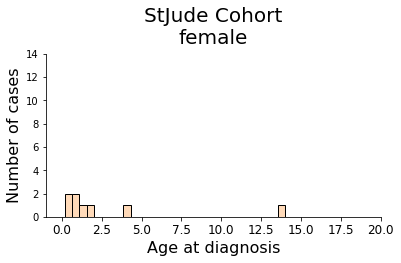

In [42]:
for cohort in ['SJD','TARGET','StJude']:
    for sex in ['Male','Female']:
        df = clinical_df[(clinical_df['SEX']==sex)&(clinical_df['COHORT']==cohort)]
        plt.figure(figsize=(6,3))
        if sex == 'Male':
            color = 'thistle'
        else:
            color = 'peachpuff'
        ages = [float(s) for s in list(df.AGE_DIAGNOSIS)]
        plt.hist(x=ages,bins=30,color=color,edgecolor='k')
        # sns.displot(ages,bins=30,kind='hist',color=color,height=3,aspect=2)
        plt.xlim(-1,20)
        plt.ylim(0,14)
        plt.xticks(size=12)
        plt.xlabel('Age at diagnosis',size=16)
        plt.ylabel('Number of cases',size=16)
        plt.title(cohort+' Cohort\n'+sex.lower(), pad=10, size=20)
        sns.despine()
        plt.show()

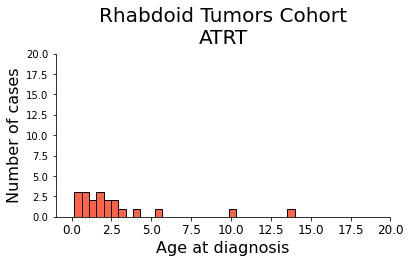

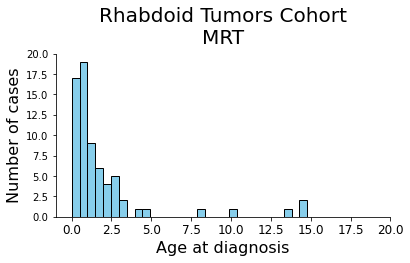

In [43]:
for ttype in ['ATRT','MRT']:
    df = clinical_df[clinical_df['TUMOR_TYPE']==ttype]
    plt.figure(figsize=(6,3))
    if ttype == 'ATRT':
        color = 'tomato'
        bins = 30
    else:
        color = 'skyblue'
        bins = 30
    ages = [float(s) for s in list(df.AGE_DIAGNOSIS)]
    plt.hist(x=ages,bins=bins,color=color,edgecolor='k')
    # sns.displot(df['AGE_DIAGNOSIS'],bins=bins,kind='hist',color=color,height=3,aspect=2)
    plt.xlim(-1,20)
    plt.ylim(0,20)
    plt.xticks(size=12)
    plt.xlabel('Age at diagnosis',size=16)
    plt.ylabel('Number of cases',size=16)
    plt.title('Rhabdoid Tumors Cohort\n'+ttype, pad=10, size=20)
    sns.despine()
    plt.show()

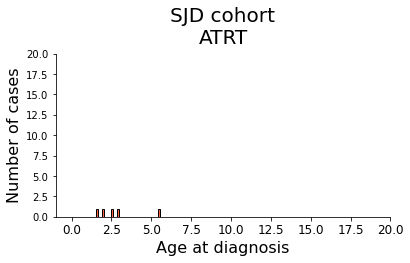

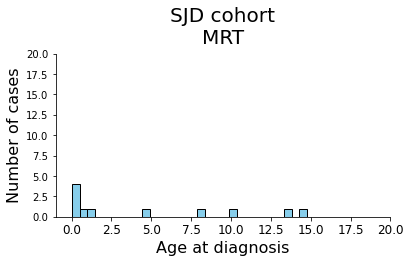

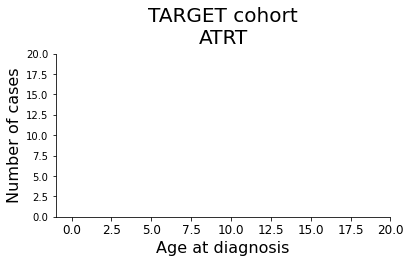

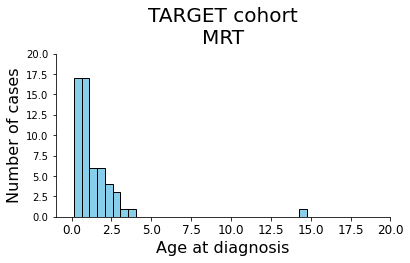

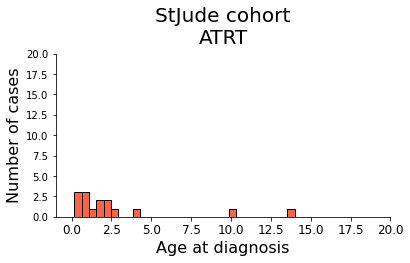

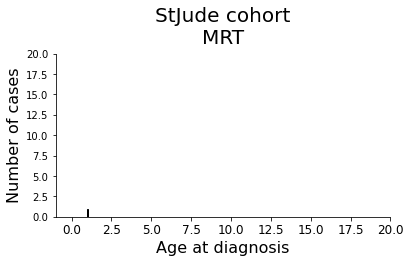

In [44]:
for cohort in ['SJD','TARGET','StJude']:
    for ttype in ['ATRT','MRT']:
        df = clinical_df[(clinical_df['TUMOR_TYPE']==ttype)&(clinical_df['COHORT']==cohort)]
        plt.figure(figsize=(6,3))
        if ttype == 'ATRT':
            color = 'tomato'
            bins = 30
        else:
            color = 'skyblue'
            bins = 30
        ages = [float(s) for s in list(df.AGE_DIAGNOSIS)]
        plt.hist(x=ages,bins=bins,color=color,edgecolor='k')
        # sns.displot(df['AGE_DIAGNOSIS'],bins=bins,kind='hist',color=color,height=3,aspect=2)
        plt.xlim(-1,20)
        plt.ylim(0,20)
        plt.xticks(size=12)
        plt.xlabel('Age at diagnosis',size=16)
        plt.ylabel('Number of cases',size=16)
        plt.title(cohort+' cohort\n'+ttype, pad=10, size=20)
        sns.despine()
        plt.show()

## Proportions

In [45]:
import numpy as np
from matplotlib import colormaps

In [46]:
print(colormaps)

ColormapRegistry; available colormaps:
'magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 'turbo_r', 'Blues_r', 'BrBG_r', 'BuGn_

[None, None, None, None, None, None, None, None, None]

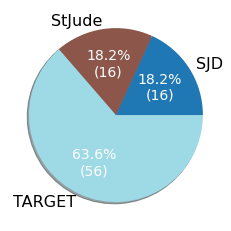

In [47]:
pastel1 = colormaps['tab20'].resampled(3)

def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%\n({absolute:d})"

grp_df = clinical_df[['COHORT','PATIENT']][clinical_df['COHORT']!='PMC'].groupby('COHORT',as_index=False).count()
values = grp_df['PATIENT'].tolist()
wedges, texts, autotexts = plt.pie(labels=grp_df['COHORT'],x=grp_df['PATIENT'],colors=pastel1.colors,autopct=lambda pct: func(pct, values),shadow=True)
# plt.title('Rhabdoid Tumors Cohort',pad=20,size=20)
plt.setp(autotexts, size=14,color='white')
plt.setp(texts, size=16,color='black')

[None, None, None, None, None, None]

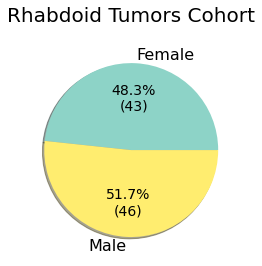

In [48]:
pastel1 = colormaps['Set3'].resampled(2)

def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%\n({absolute:d})"

grp_df = clinical_df[['SEX','PATIENT']].groupby('SEX',as_index=False).count()
values = grp_df['PATIENT'].tolist()
wedges, texts, autotexts = plt.pie(labels=grp_df['SEX'],x=grp_df['PATIENT'],colors=pastel1.colors,autopct=lambda pct: func(pct, values),shadow=True)
plt.title('Rhabdoid Tumors Cohort',pad=20,size=20)
plt.setp(autotexts, size=14,color='black')
plt.setp(texts, size=16,color='black')

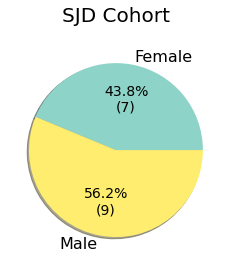

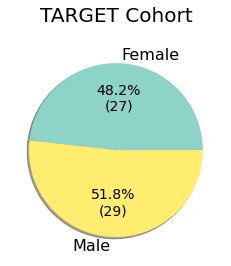

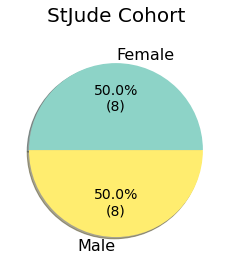

In [49]:
for cohort in ['SJD','TARGET','StJude']:
    cohort_df = clinical_df[clinical_df['COHORT']==cohort]
    grp_df = cohort_df[['SEX','PATIENT']].groupby('SEX',as_index=False).count()
    values = grp_df['PATIENT'].tolist()
    wedges, texts, autotexts = plt.pie(labels=grp_df['SEX'],x=grp_df['PATIENT'],colors=pastel1.colors,autopct=lambda pct: func(pct, values),shadow=True)
    plt.title(cohort+' Cohort',pad=20,size=20)
    plt.setp(autotexts, size=14,color='black')
    plt.setp(texts, size=16,color='black')
    plt.show()

In [50]:
colormaps.keys()

KeysView(<matplotlib.cm.ColormapRegistry object at 0x14d457aa77c0>)

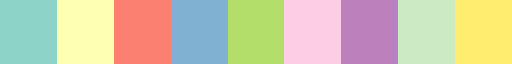

In [51]:
pastel1 = colormaps['Set3'].resampled(9)
pastel1

In [52]:
pastel1.colors

array([[0.55294118, 0.82745098, 0.78039216, 1.        ],
       [1.        , 1.        , 0.70196078, 1.        ],
       [0.98431373, 0.50196078, 0.44705882, 1.        ],
       [0.50196078, 0.69411765, 0.82745098, 1.        ],
       [0.70196078, 0.87058824, 0.41176471, 1.        ],
       [0.98823529, 0.80392157, 0.89803922, 1.        ],
       [0.7372549 , 0.50196078, 0.74117647, 1.        ],
       [0.8       , 0.92156863, 0.77254902, 1.        ],
       [1.        , 0.92941176, 0.43529412, 1.        ]])

Text(0.5, 1.0, 'Primary Tumor Site')

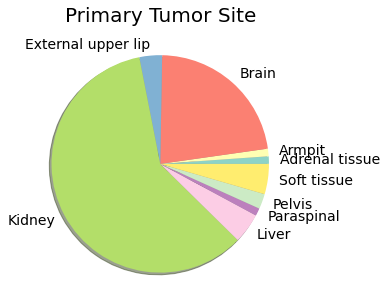

In [53]:
def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{int(pct)}%\n({absolute:d})"

pastel1 = colormaps['Set3'].resampled(9)
grp_df = clinical_df[['PRY_TUMOR_SITE','PATIENT']].groupby('PRY_TUMOR_SITE',as_index=False).count()
values = grp_df['PATIENT'].tolist()

plt.figure(figsize=(5,5))
wedges, texts = plt.pie(labels=grp_df['PRY_TUMOR_SITE'],x=grp_df['PATIENT'],shadow=True,colors=pastel1.colors, pctdistance=0.8)

plt.setp(texts, size=14,color='black')
plt.title('Primary Tumor Site',size=20)

In [54]:
sites = grp_df['PRY_TUMOR_SITE']
pastel1 = colormaps['Set3'].resampled(len(sites))
color_site_dict = {}
n=0
for site in sites:
    color_site_dict[site] = list(pastel1.colors[n])
    n=n+1
color_site_dict

{'Adrenal tissue': [0.5529411764705883,
  0.8274509803921568,
  0.7803921568627451,
  1.0],
 'Armpit': [1.0, 1.0, 0.7019607843137254, 1.0],
 'Brain': [0.984313725490196, 0.5019607843137255, 0.4470588235294118, 1.0],
 'External upper lip': [0.5019607843137255,
  0.6941176470588235,
  0.8274509803921568,
  1.0],
 'Kidney': [0.7019607843137254, 0.8705882352941177, 0.4117647058823529, 1.0],
 'Liver': [0.9882352941176471, 0.803921568627451, 0.8980392156862745, 1.0],
 'Paraspinal': [0.7372549019607844,
  0.5019607843137255,
  0.7411764705882353,
  1.0],
 'Pelvis': [0.8, 0.9215686274509803, 0.7725490196078432, 1.0],
 'Soft tissue': [1.0, 0.9294117647058824, 0.43529411764705883, 1.0]}

In [55]:
# color_site_dict = {'Pelvis':'bisque',
#                   'Kidney':'gold',
#                   'Soft tissue':'lightgreen',
#                   'Paraspinal':'pink',
#                   'Brain':'coral',
#                   'Liver':'yellowgreen',
#                   'Armpit':'cornsilk',
#                   'Adrenal tissue':'turquoise',
#                   'External upper lip':'cadetblue'}

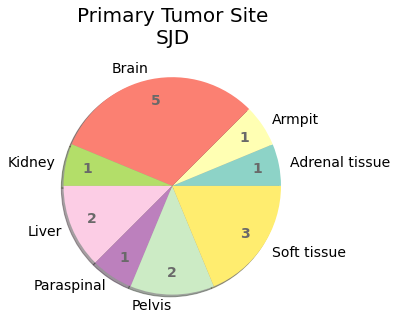

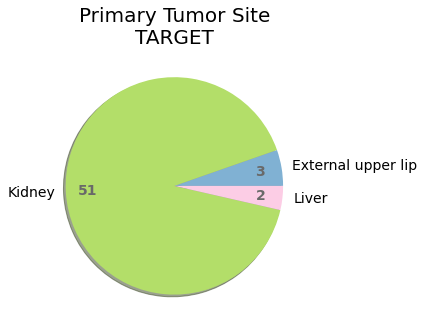

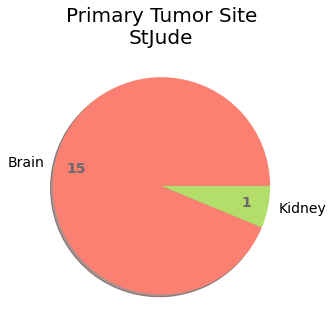

In [57]:
for cohort in ['SJD','TARGET','StJude']:
    cohort_df = clinical_df[clinical_df['COHORT']==cohort]
    grp_df = cohort_df[['PRY_TUMOR_SITE','PATIENT']].groupby('PRY_TUMOR_SITE',as_index=False).count()
    sites = grp_df['PRY_TUMOR_SITE']
    colors = np.array([color_site_dict[site] for site in sites])
    values = grp_df['PATIENT'].tolist()
    
    def absolute_value(val):
        # Calculate the corresponding count from the percentage
        # 'values' is the list of counts (values) for the current cohort
        a  = np.round(val/100.*sum(values))
        return f'{int(a)}' # Return the count as a string (without the percentage sign)

    plt.figure(figsize=(5,5))
    wedges, texts, autotexts = plt.pie(labels=grp_df['PRY_TUMOR_SITE'],
                                       x=grp_df['PATIENT'],
                                       shadow=True,
                                       colors=colors,
                                       autopct=absolute_value,
                                       pctdistance=0.8)

    plt.setp(texts, size=14,color='black')
    plt.setp(autotexts, size=14, color='dimgrey', fontweight='bold') # For the count labels
    plt.title('Primary Tumor Site\n'+cohort,size=20)
    plt.savefig('plots/primary_tumor_site'+cohort+'.svg', bbox_inches='tight',format='svg')

## Load table with mutation data

In [58]:
smarcb1_df = pd.read_csv('variant_calling/Summary_SMARCB1_alterations.tsv',sep='\t', skiprows=1)
smarcb1_df

,PATIENT,TUMOR,SAMPLE,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,...,Germline CNA,mut_sv,fusion,chr/chr,germ_som,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples
0,pt1,tumor1,AX4912_vs_AX4894,SJD,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,-,NaN,NaN,NaN,False,False,del / del,NaN,NaN,NaN
1,pt1,tumor2,AX4937_vs_AX4894,SJD,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,del / del,NaN,NaN,NaN
2,pt3,tumor1,AX4914_vs_AX4895,SJD,SMARCB1,truncating,stop_gained,R40*,chr22:23791780:C>T,1,...,-,nan:23787300:C>]chr22:23785923]C,SMARCB1/-,chr22,False,False,R40* / exon1-del,NaN,23785923-23787300,NaN
3,pt3,tumor2,AX4915_vs_AX4895,SJD,SMARCB1,truncating,stop_gained,R40*,chr22:23791780:C>T,1,...,-,nan:23787300:C>]chr22:23785923]C,SMARCB1/-,chr22,False,False,R40* / exon1-del,NaN,23785923-23787300,NaN
4,pt4,tumor1,AX4916_vs_AX4896,SJD,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,-,NaN,NaN,NaN,False,True,del / CNLOH,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,SJ063832,tumor1,SJMRT063832_X1_vs_SJMRT063832_G1,St Jude,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,False,del / del,NaN,NaN,Excluded due to xenograft sample
112,PMC01,tumor1,DIAF_vs_BLOOD,PMC,SMARCB1,truncating,frameshift_variant,PS48-49X,chr22:23791806:CTCA>-,1.980902,...,NaN,NaN,NaN,NaN,False,True,PS48-49X / CNLOH,NaN,NaN,NaN
113,PMC01,tumor2,OMEN_vs_BLOOD,PMC,SMARCB1,truncating,frameshift_variant,PS48-49X,chr22:23791806:CTCA>-,2.208627,...,NaN,NaN,NaN,NaN,False,True,PS48-49X / CNLOH,NaN,NaN,NaN
114,PMC01,tumor3,LN_vs_BLOOD,PMC,SMARCB1,truncating,frameshift_variant,PS48-49X,chr22:23791806:CTCA>-,2.012602,...,NaN,NaN,NaN,NaN,False,True,PS48-49X / CNLOH,NaN,NaN,NaN


In [59]:
smarcb1_df = smarcb1_df[smarcb1_df['Excluded_samples'].isnull()]

In [60]:
smarcb1_df.groupby('SAMPLE').count()

,PATIENT,TUMOR,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,origin,...,Germline CNA,mut_sv,fusion,chr/chr,germ_som,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples
SAMPLE,,,,,,,,,,,,,,,,,,,,,
AX4912_vs_AX4894,1,1,1,1,0,0,0,0,0,1,...,1,0,0,0,1,1,1,0,0,0
AX4914_vs_AX4895,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,0
AX4915_vs_AX4895,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,0
AX4916_vs_AX4896,1,1,1,1,0,0,0,0,0,1,...,1,0,0,0,1,1,1,0,0,0
AX4918_vs_AX4897,1,1,1,1,0,0,0,0,0,1,...,1,0,0,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SJBT032417_D2_vs_SJBT032417_G1,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,1,1,1,0,0,0
SJBT033236_D2_vs_SJBT033236_G1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,1,1,0,0,0
SJBT034089_D1_vs_SJBT034089_G1,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,1,1,1,0,0,0


In [61]:
smarcb1_df.groupby(['PATIENT']).count()

,TUMOR,SAMPLE,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,origin,...,Germline CNA,mut_sv,fusion,chr/chr,germ_som,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples
PATIENT,,,,,,,,,,,,,,,,,,,,,
PABKLN,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,1,1,0,0,0
PADWRZ,1,1,1,1,1,1,1,1,1,1,...,0,1,1,1,1,1,1,0,0,0
PADYZI,2,2,2,2,2,2,2,2,2,2,...,0,0,0,0,1,2,2,0,0,0
PAEHIP,1,1,1,1,0,0,0,0,0,1,...,0,1,1,1,1,1,1,0,0,0
PAJLWM,1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pt5,2,2,2,2,0,0,0,0,0,2,...,2,0,0,0,2,2,2,0,0,0
pt6,2,2,2,2,2,2,2,2,2,2,...,2,0,0,0,2,2,2,0,0,0
pt7,1,1,1,1,0,0,0,0,0,1,...,1,1,1,1,1,1,1,1,0,0


In [62]:
smarcb1_df[['COHORT','PATIENT']].drop_duplicates().groupby(['COHORT']).count()

,PATIENT
COHORT,
PMC,1
SJD,16
St Jude,16
TARGET,56


In [63]:
clinical_df[['COHORT','PATIENT']].groupby('COHORT').count()

,PATIENT
COHORT,
PMC,1
SJD,16
StJude,16
TARGET,56


In [64]:
smarcb1_df.columns

Index(['PATIENT', 'TUMOR', 'SAMPLE', 'COHORT', 'SYMBOL', 'variant_type',
       'Consequence', 'aa_change', 'mut', 'Damaging', 'origin', 'VAF', 'CNA',
       'CN', 'Germline CNA', 'mut_sv', 'fusion', 'chr/chr', 'germ_som',
       'CNLOH', 'SMARCB1 status', 'chr22_del_a1', 'chr22_del_a2',
       'Excluded_samples'],
      dtype='object')

In [65]:
# smarcb1_df = smarcb1_df[~smarcb1_df['SMARCB1 status'].str.contains('MYCN')]
smarcb1_df['allele1'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[0]
smarcb1_df['allele2'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[1]
smarcb1_df['origin_a1'] = smarcb1_df['allele1'].apply(lambda x: 'germline' if 'germline' in x else 'somatic')
smarcb1_df['origin_a2'] = smarcb1_df['allele2'].apply(lambda x: 'germline' if 'germline' in x else 'somatic')
smarcb1_df['germline'] = smarcb1_df['SMARCB1 status'].str.contains('germline')
smarcb1_df['CNLOH'] = smarcb1_df['SMARCB1 status'].str.contains('CNLOH')
smarcb1_df['COHORT'] = smarcb1_df['COHORT'].replace('St Jude','StJude')
smarcb1_df[['PATIENT','SMARCB1 status','allele1','allele2','origin_a1','origin_a2','germline']].drop_duplicates()

/tmp/ipykernel_3311154/2682153593.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smarcb1_df['allele1'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[0]
/tmp/ipykernel_3311154/2682153593.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smarcb1_df['allele2'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[1]
/tmp/ipykernel_3311154/2682153593.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

,PATIENT,SMARCB1 status,allele1,allele2,origin_a1,origin_a2,germline
0,pt1,del / del,del,del,somatic,somatic,False
2,pt3,R40* / exon1-del,R40*,exon1-del,somatic,somatic,False
4,pt4,del / CNLOH,del,CNLOH,somatic,somatic,False
6,pt5,del / del,del,del,somatic,somatic,False
8,pt6,S66SX / CNLOH,S66SX,CNLOH,somatic,somatic,False
...,...,...,...,...,...,...,...
106,SJ032417,del / CNLOH,del,CNLOH,somatic,somatic,False
108,SJ033236,splice variant / chrom loss,splice variant,chrom loss,somatic,somatic,False
109,SJ034089,del / del,del,del,somatic,somatic,False
110,SJ034110,I99ILDX (exon3-ins8) / del,I99ILDX (exon3-ins8),del,somatic,somatic,False


## CNLOH

In [66]:
smarcb1_df[['PATIENT','CNLOH','COHORT']][smarcb1_df['SYMBOL']!='MYCN'].drop_duplicates().groupby(['CNLOH','COHORT']).count()

PATIENT
CNLOH COHORT         
False SJD          11
      StJude       11
      TARGET       29
True  PMC           1
      SJD           5
      StJude        5
      TARGET       26

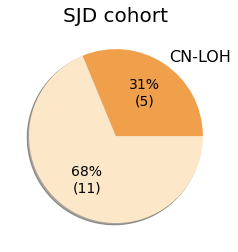

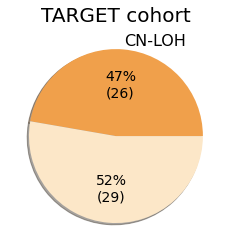

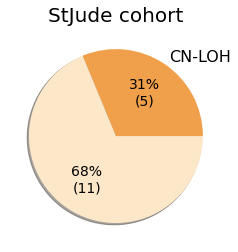

In [67]:
for cohort in ['SJD','TARGET','StJude']:
    df = smarcb1_df[['PATIENT','COHORT','CNLOH']][(smarcb1_df['SYMBOL']!='MYCN')&(smarcb1_df['COHORT']==cohort)].drop_duplicates()
    true = len(df[df['CNLOH']==True])
    false = len(df[df['CNLOH']==False])
    values = [true, false]
    wedges, texts, autotexts = plt.pie(labels=['CN-LOH',''],x=values,colors=['#F0A04B','#FCE7C8'],autopct=lambda pct: func(pct, values),shadow=True)
    plt.setp(autotexts, size=14,color='black')
    plt.setp(texts, size=16,color='black')
    plt.title(cohort+' cohort',size=20)
    plt.show()

In [68]:
clinical_df.groupby('COHORT').count()

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE
COHORT,,,,,
PMC,1,1,1,1,1
SJD,16,16,16,16,16
StJude,16,16,16,16,16
TARGET,56,56,56,56,56


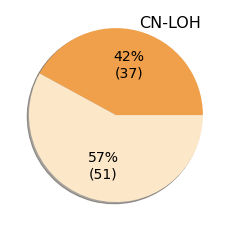

In [69]:
df = smarcb1_df[['PATIENT','CNLOH']][smarcb1_df['SYMBOL']!='MYCN'].drop_duplicates()
true = len(df[df['CNLOH']==True])
false = len(df[df['CNLOH']==False])
values = [true, false]
wedges, texts, autotexts = plt.pie(labels=['CN-LOH',''],x=values,colors=['#F0A04B','#FCE7C8'],autopct=lambda pct: func(pct, values),shadow=True)
plt.setp(autotexts, size=14,color='black')
plt.setp(texts, size=16,color='black')
# plt.title('Rhabdoid Tumors Cohort',size=20)
plt.savefig('plots/cnloh_piechart.svg', bbox_inches='tight',format='svg')

## Driver SMARCB1 / SMARCA4

In [70]:
smarcb1_df[['PATIENT','SYMBOL']].drop_duplicates().groupby('SYMBOL').count()

,PATIENT
SYMBOL,
MYCN,1
SMARCA4,2
SMARCB1,86


In [71]:
['#FBF5E5','#C890A7','red']

['#FBF5E5', '#C890A7', 'red']

In [72]:
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viridis_r',
 'cividis_r',
 'twilight_r',
 'twilight

In [73]:
symbol = smarcb1_df['SYMBOL'].unique()
pastel1 = colormaps['crest'].resampled(len(symbol))
color_symbol_dict = {}
n=0
for s in symbol:
    color_symbol_dict[s] = list(pastel1.colors[n])
    n=n+1
color_symbol_dict

{'SMARCB1': [0.6468274, 0.80289262, 0.56592265, 1.0],
 'SMARCA4': [0.20094292, 0.52087429, 0.55342884, 1.0],
 'MYCN': [0.17363177, 0.19076859, 0.44549087, 1.0]}

['SMARCA4', 'SMARCB1']


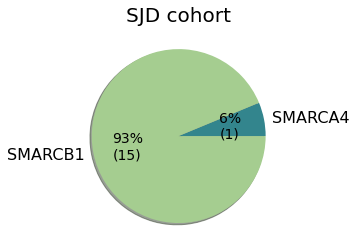

['MYCN', 'SMARCA4', 'SMARCB1']


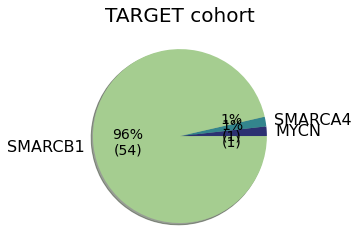

['SMARCB1']


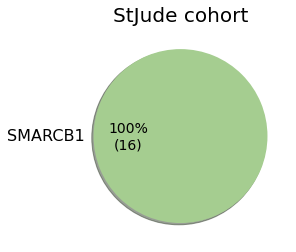

In [74]:
for cohort in ['SJD','TARGET','StJude']:
    df = smarcb1_df[['PATIENT','SYMBOL','COHORT']][smarcb1_df['COHORT']==cohort].drop_duplicates().groupby('SYMBOL').count()
    labels = list(df.index)
    print(labels)
    values = list(df['PATIENT'])
    colors = np.array([color_symbol_dict[s] for s in labels])
    wedges, texts, autotexts = plt.pie(labels=labels,x=values,colors=colors,autopct=lambda pct: func(pct, values),shadow=True)
    plt.setp(autotexts, size=14,color='black')
    plt.setp(texts, size=16,color='black')
    plt.title(cohort+' cohort',size=20)
    plt.show()

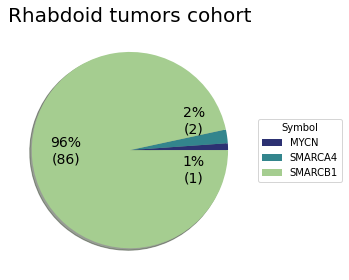

In [75]:

df = smarcb1_df[['PATIENT','SYMBOL','COHORT']].drop_duplicates().groupby('SYMBOL').count()
labels = list(df.index)
values = list(df['PATIENT'])
colors = np.array([color_symbol_dict[s] for s in labels])
# wedges, texts, autotexts = plt.pie(labels=labels,x=values,colors=colors,autopct=lambda pct: func(pct, values),shadow=True)
# plt.setp(autotexts, size=14,color='black')
# plt.setp(texts, size=16,color='black')
# plt.title('Rhabdoid tumors cohort',size=20)
# plt.tight_layout()
# plt.show()

wedges, texts, autotexts = plt.pie(
    x=values,
    colors=colors,
    autopct=lambda pct: func(pct, values),
    shadow=True,
    textprops={'fontsize': 12, 'color': 'black'},  # Smaller font
)

custom_x = [0.65,0.65,-0.65]
custom_y = [-0.2,0.3,0]
# Manually adjust autotext positions
for i, autotext in enumerate(autotexts):
    autotext.set_position((custom_x[i], custom_y[i]))  # Set your own coordinates

plt.legend(wedges, labels, title="Symbol", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.setp(autotexts, size=14, color='black')
plt.title('Rhabdoid tumors cohort', size=20)
plt.tight_layout()
plt.show()

### Germline

In [76]:
smarcb1_df[['PATIENT','germline']][smarcb1_df['SYMBOL']!='MYCN'].drop_duplicates().groupby(['germline']).count()

,PATIENT
germline,
False,70
True,18


In [77]:
smarcb1_df[['PATIENT','origin_a1','origin_a2']][smarcb1_df['SYMBOL']!='MYCN'].drop_duplicates().groupby(['origin_a2']).count()

,PATIENT,origin_a1
origin_a2,,
germline,1,1
somatic,87,87


In [78]:
smarcb1_df[smarcb1_df['origin_a2']=='germline']

,PATIENT,TUMOR,SAMPLE,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,...,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline
31,PADYZI,tumor1,PADYZI-01A_vs_PADYZI-10A,TARGET,SMARCB1,truncating,stop_gained,W206*,chr22:23803411:G>A,TRUE,...,False,W206* germline / F10X germline,NaN,NaN,NaN,W206* germline,F10X germline,germline,germline,True
32,PADYZI,tumor2,PADYZI-01A_vs_PADYZI-10A,TARGET,SMARCB1,truncating,frameshift_variant,F10X,chr22:23787197:TT>-,TRUE,...,False,W206* germline / F10X germline,NaN,NaN,NaN,W206* germline,F10X germline,germline,germline,True


In [79]:
symbol = smarcb1_df['SYMBOL'].unique()
pastel1 = colormaps['crest'].resampled(len(symbol))
color_symbol_dict = {}
n=0
for s in symbol:
    color_symbol_dict[s] = list(pastel1.colors[n])
    n=n+1
color_symbol_dict

{'SMARCB1': [0.6468274, 0.80289262, 0.56592265, 1.0],
 'SMARCA4': [0.20094292, 0.52087429, 0.55342884, 1.0],
 'MYCN': [0.17363177, 0.19076859, 0.44549087, 1.0]}

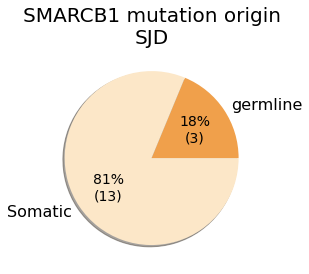

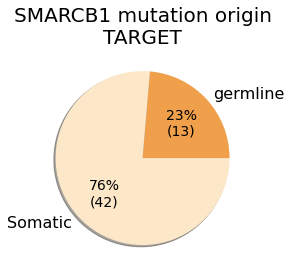

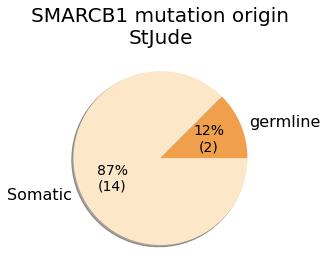

In [80]:
for cohort in ['SJD','TARGET','StJude']:
    df = smarcb1_df[['PATIENT','germline','COHORT']][(smarcb1_df['SYMBOL']!='MYCN')&(smarcb1_df['COHORT']==cohort)].drop_duplicates()
    true = len(df[df['germline']==True])
    false = len(df[df['germline']==False])
    values = [true, false]
    wedges, texts, autotexts = plt.pie(labels=['germline','Somatic'],x=values,colors=['#F0A04B','#FCE7C8'],autopct=lambda pct: func(pct, values),shadow=True)
    plt.setp(autotexts, size=14,color='black')
    plt.setp(texts, size=16,color='black')
    plt.title('SMARCB1 mutation origin\n'+cohort,size=20)
    plt.show()